In [21]:
#1: Load Data and Initial Processing
import numpy as np
import pandas as  pd 


dataset = pd.read_csv('Telco-Customer-Churn.csv')
dataset.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
#2 : Data Processing and Formatting 

#1 Drop Customer ID as it is not useful for Analysis Purposes 
dataset.drop('customerID', axis=1, inplace=True)

dataset.info()

#2 Convert Total Charges to Numeric as it is currently in Object format
dataset['TotalCharges']= pd.to_numeric(dataset['TotalCharges'], errors='coerce')

#3Check for Missing Values 
dataset.isnull().sum()
## We can see that there are 11 missing values in TotalCharges column. We will handle this in the next step.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [23]:
#3: Missing Data Handling 

# Look at the rows where TotalCharges is missing
dataset[dataset['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

# We can see that the tenure is 0 for all these rows, which means these customers have just joined and haven't been charged yet.
# We can fill the missing TotalCharges with 0 for these customers.
dataset['TotalCharges']= dataset['TotalCharges'].fillna(dataset['TotalCharges'].median())
dataset.isnull().sum()


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

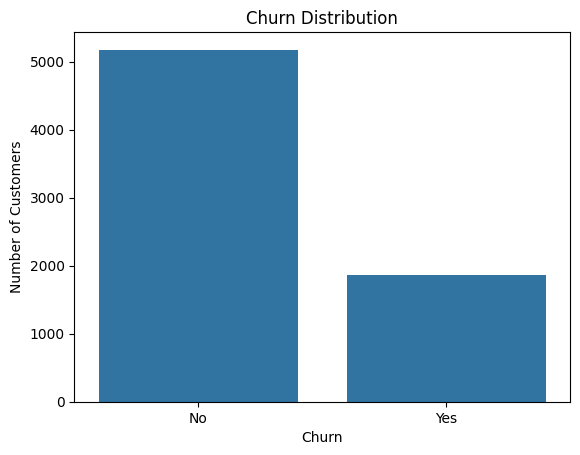

Baseline Churn Rate: 26.54%


In [24]:
#3: Baseline Churn Rate Calculation
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.countplot(x='Churn', data=dataset)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()
churn_rate = dataset['Churn'].value_counts(normalize=True)['Yes']
print(f'Baseline Churn Rate: {churn_rate:.2%}')
## The baseline churn rate is the percentage of customers who have churned in the dataset. This gives us a reference point to compare against when we build our predictive models.


In [30]:
#4 ML Data Preparation
import pandas as pd 
import numpy as np

ml_dataset = dataset.copy()

ml_dataset['Churn'] = ml_dataset['Churn'].map({'Yes': 1, 'No': 0})
ml_dataset.head()

categorical_cols = ml_dataset.select_dtypes(include=['object']).columns.tolist()
ml_dataset = pd.get_dummies(ml_dataset, columns=categorical_cols, drop_first=True)

ml_dataset = ml_dataset.astype(float, errors='ignore')
ml_dataset.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,29.85,29.85,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,34.0,56.95,1889.50,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,2.0,53.85,108.15,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,45.0,42.30,1840.75,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,2.0,70.70,151.65,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [32]:
#5: Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

X = ml_dataset.drop('Churn', axis=1)
y = ml_dataset['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols= ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])







In [33]:
#6 Model Building and Evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f'ROC AUC Score: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}')

              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88      1036
         1.0       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409

[[934 102]
 [149 224]]
ROC AUC Score: 0.8622


/var/folders/zc/5ryk00qj6190rnt5sc3ryslr0000gn/T/ipykernel_23834/3015033068.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='viridis')


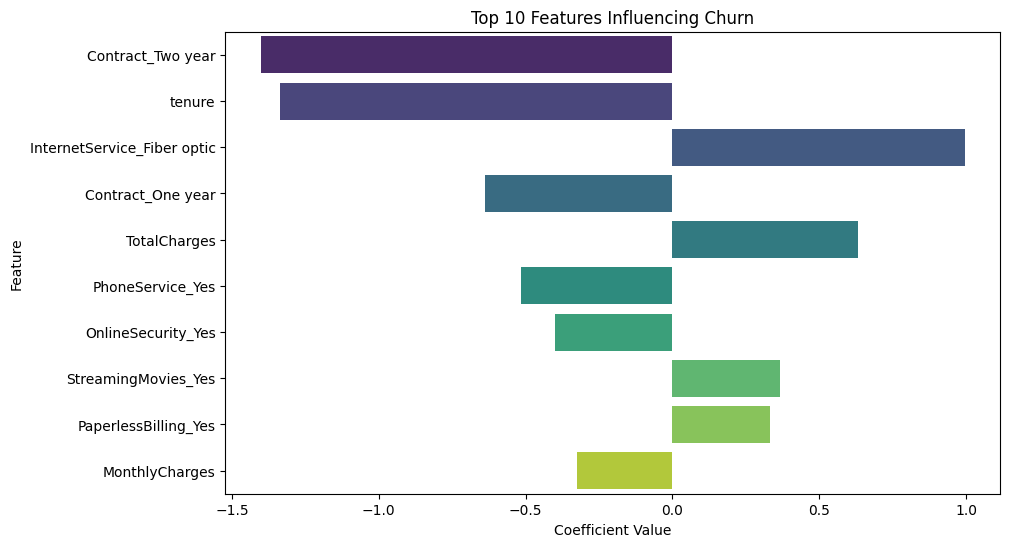

In [36]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefficients['AbsCoefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='AbsCoefficient', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='viridis')
plt.title('Top 10 Features Influencing Churn')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()


In [39]:
import pandas as pd
import numpy as np

# 1. Reload the original data to make sure we map back to the real customer IDs
original_df = pd.read_csv("Telco-Customer-Churn.csv")

# 2. Re-scale the entire dataset features using our already fitted scaler
# (This ensures the formatting perfectly matches what the model expects)
X_all = X.copy()
X_all[num_cols] = scaler.transform(X_all[num_cols])

# 3. Calculate the EXACT probability of churn for every single customer
# [:, 1] grabs the probability of the customer being class 1 (Churn)
all_probabilities = model.predict_proba(X_all)[:, 1]

# 4. Build a comprehensive Risk Report DataFrame
risk_report = pd.DataFrame({
    'CustomerID': original_df['customerID'],
    'Current_Status': original_df['Churn'],
    'Churn_Probability': all_probabilities,
    'Tenure_Months': original_df['tenure'],
    'Monthly_Bill': original_df['MonthlyCharges'],
    'Contract_Type': original_df['Contract'],
    'Internet_Service': original_df['InternetService'],
    'Payment_Method': original_df['PaymentMethod']
})

# 5. FILTER: We only care about active customers who have NOT left yet (Current_Status == 'No')
active_customers = risk_report[risk_report['Current_Status'] == 'No'].copy()

# 6. Segment active customers into actionable Business Tiers
def assign_risk_tier(prob):
    if prob >= 0.70:
        return 'High Risk (Immediate Action)'
    elif prob >= 0.30:
        return 'Medium Risk (Monitor/Nurture)'
    else:
        return 'Low Risk (Loyal)'

active_customers['Risk_Tier'] = active_customers['Churn_Probability'].apply(assign_risk_tier)

# Sort from highest risk to lowest risk
active_customers = active_customers.sort_values(by='Churn_Probability', ascending=False)

# Save this out as a clean file for the marketing department
active_customers.to_csv("Active_Customer_Churn_Risk_Report.csv", index=False)

# Display the size of each risk tier
print("--- Active Customer Risk Tier Distribution ---")
print(active_customers['Risk_Tier'].value_counts())

print("\n--- Top 5 Active Customers Most Likely to Leave Next Month ---")
active_customers[['CustomerID', 'Churn_Probability', 'Risk_Tier', 'Contract_Type', 'Internet_Service']].head()

--- Active Customer Risk Tier Distribution ---
Risk_Tier
Low Risk (Loyal)                 3950
Medium Risk (Monitor/Nurture)    1142
High Risk (Immediate Action)       82
Name: count, dtype: int64

--- Top 5 Active Customers Most Likely to Leave Next Month ---


,CustomerID,Churn_Probability,Risk_Tier,Contract_Type,Internet_Service
3159,5150-ITWWB,0.828761,High Risk (Immediate Action),Month-to-month,Fiber optic
3346,2545-EBUPK,0.816056,High Risk (Immediate Action),Month-to-month,Fiber optic
935,6630-UJZMY,0.798458,High Risk (Immediate Action),Month-to-month,Fiber optic
4039,8161-QYMTT,0.787152,High Risk (Immediate Action),Month-to-month,Fiber optic
5213,7668-XCFYV,0.785534,High Risk (Immediate Action),Month-to-month,Fiber optic
